# Programming in Python assignment 1

## Jan Michalski 251590, Bartosz Danielak 251498

### Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

### Importing data from CSV

In [2]:
data = pd.read_csv("data.csv")
columns_names = ["Sex","Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight","Rings"]
columns_names_without_sex = ["Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight","Rings"]
data.columns = columns_names

### 1. Frequency distribution of Sex (Counts and Percentages)


In [3]:
counts = data["Sex"].value_counts()
percents = data["Sex"].value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    "count": counts,
    "%": percents.round(2)
})
distribution_table.index=["Male","Infant","Female"]
distribution_table

,count,%
Male,1527,36.57
Infant,1342,32.14
Female,1307,31.30


### 2. Summary statistics for quantitative variables — descriptive table

In [4]:
statistics_table = pd.DataFrame(data).describe().round(2).drop("count").T
statistics_table                        

,mean,std,min,25%,50%,75%,max
Length,0.52,0.12,0.08,0.45,0.55,0.62,0.82
Diameter,0.41,0.10,0.06,0.35,0.42,0.48,0.65
Height,0.14,0.04,0.00,0.12,0.14,0.16,1.13
Whole weight,0.83,0.49,0.00,0.44,0.80,1.15,2.83
Shucked weight,0.36,0.22,0.00,0.19,0.34,0.50,1.49
Viscera weight,0.18,0.11,0.00,0.09,0.17,0.25,0.76
Shell weight,0.24,0.14,0.00,0.13,0.23,0.33,1.00
Rings,9.93,3.22,1.00,8.00,9.00,11.00,29.00


### 3. Distribution of qualitative data — category counts


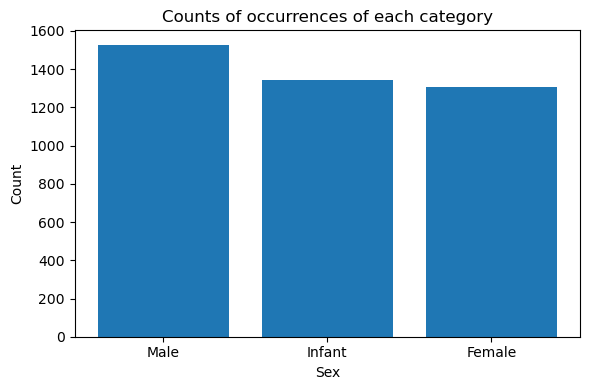

In [5]:
plt.figure(figsize=(6,4))
plt.bar(x=distribution_table.index,height=distribution_table["count"])
plt.title('Counts of occurrences of each category')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4. Distribution of quantitative variables — histograms

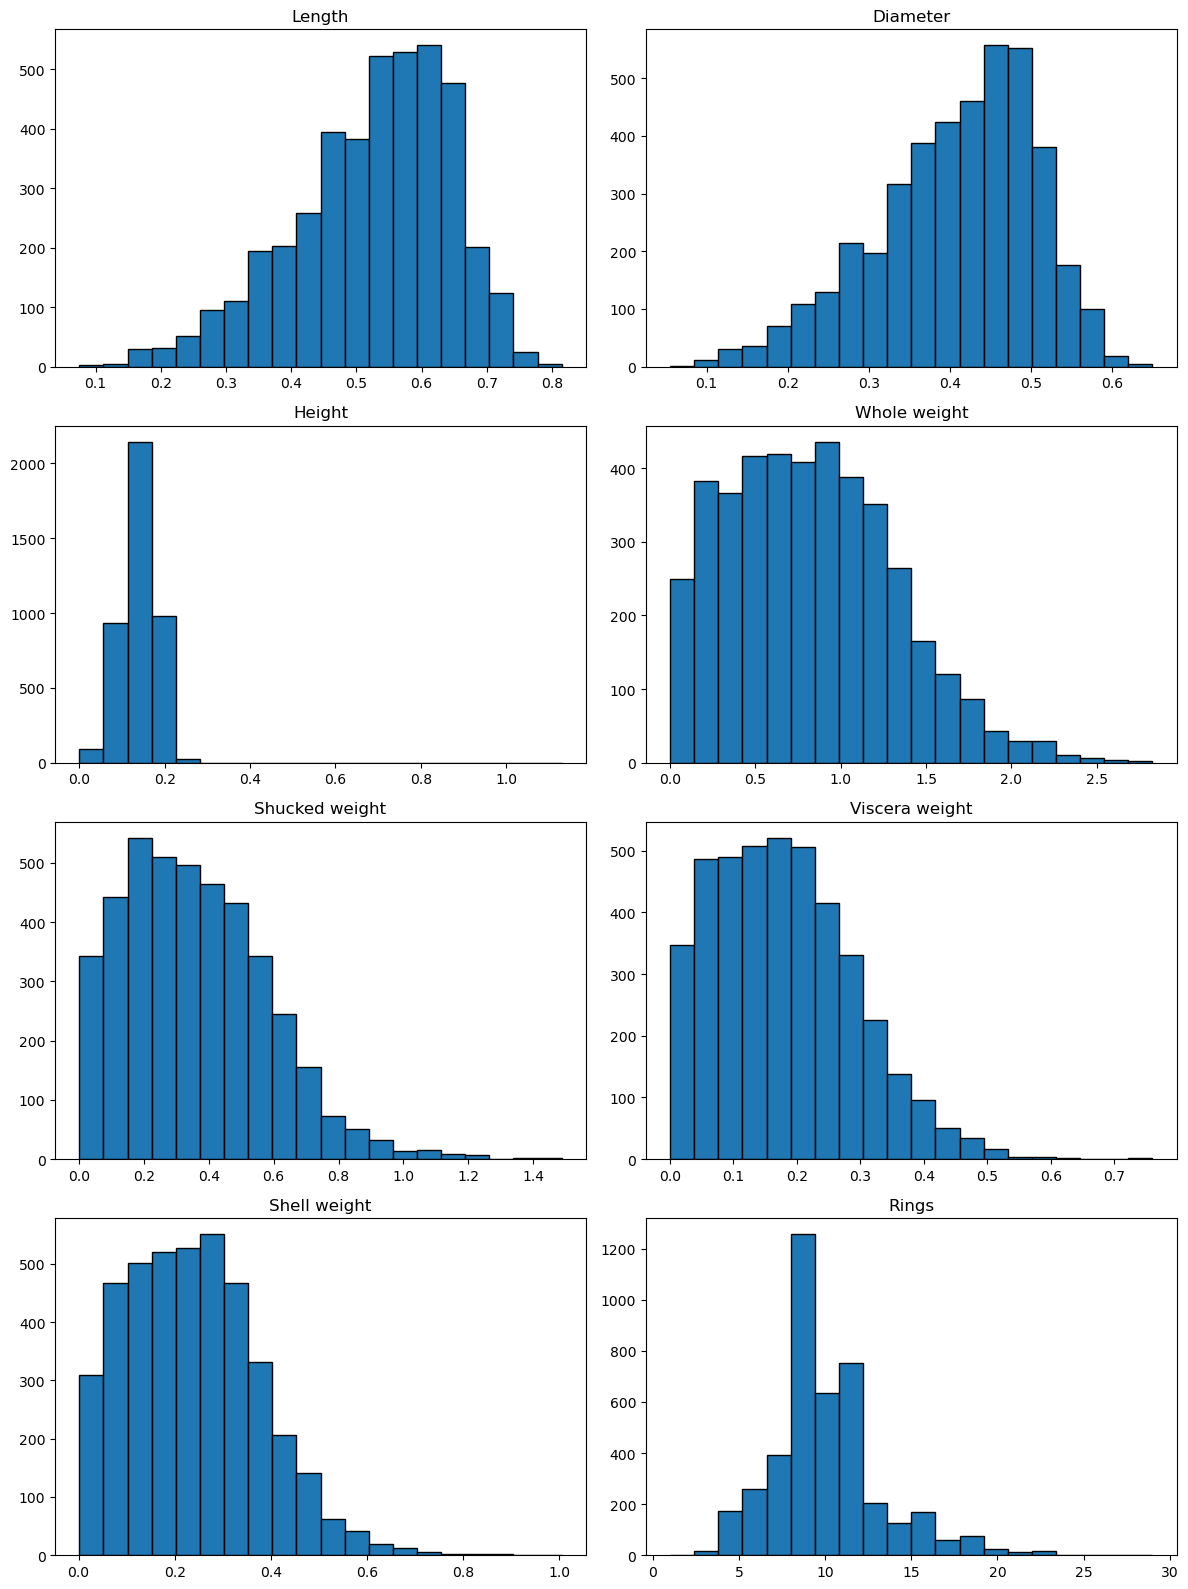

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,16))
axes = axes.flatten()
no_sex_data = data.drop("Sex",axis=1)

for ax, column_name in zip(axes, no_sex_data.columns):
    ax.hist(no_sex_data[column_name],edgecolor="black",bins=20)
    ax.set_title(column_name)

plt.tight_layout()
plt.show()

### 5. Pairwise scatter plots of quantitative variables

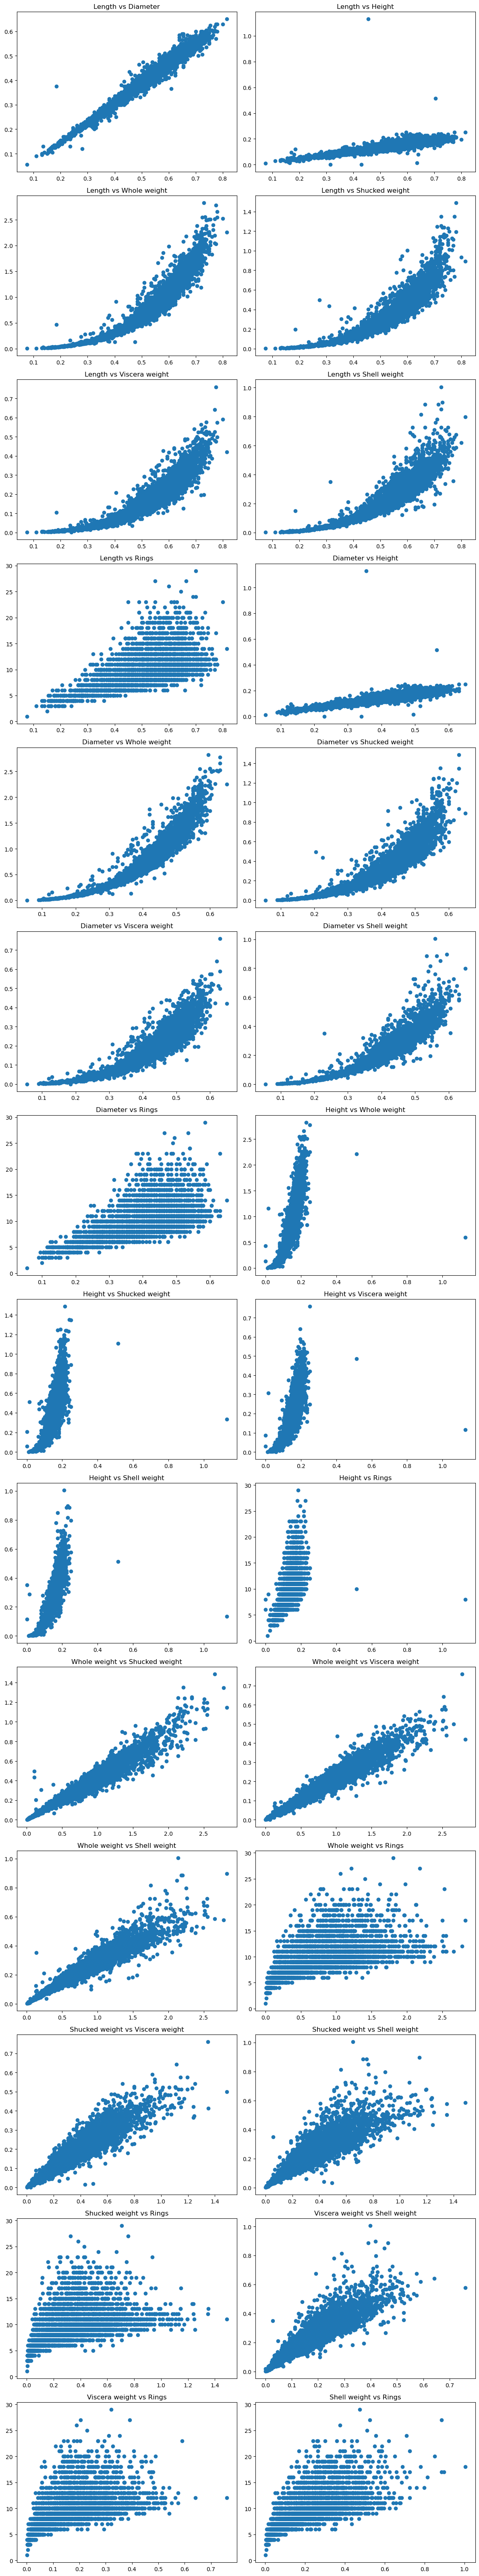

In [7]:
pairs = list(itertools.combinations(no_sex_data.columns,2))
fig, axes = plt.subplots(nrows=14,ncols=2, figsize=(12,64))
axes = axes.flatten()
for ax, (x_var,y_var) in zip(axes,pairs):
    ax.scatter(x=no_sex_data[x_var],y=no_sex_data[y_var])
    ax.set_title(f"{x_var} vs {y_var}")

plt.tight_layout()
plt.show()

### 6. Correlation matrix (Pearson) — tabular summary of linear relationships

In [8]:
correlation_matrix = data[columns_names_without_sex].corr()
correlation_matrix

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986813,0.827552,0.925255,0.897905,0.903010,0.897697,0.557123
Diameter,0.986813,1.000000,0.833705,0.925452,0.893159,0.899726,0.905328,0.575005
Height,0.827552,0.833705,1.000000,0.819209,0.774957,0.798293,0.817326,0.558109
Whole weight,0.925255,0.925452,0.819209,1.000000,0.969403,0.966372,0.955351,0.540818
Shucked weight,0.897905,0.893159,0.774957,0.969403,1.000000,0.931956,0.882606,0.421256
Viscera weight,0.903010,0.899726,0.798293,0.966372,0.931956,1.000000,0.907647,0.504274
Shell weight,0.897697,0.905328,0.817326,0.955351,0.882606,0.907647,1.000000,0.628031
Rings,0.557123,0.575005,0.558109,0.540818,0.421256,0.504274,0.628031,1.000000


### 7. Heatmap of Pearson correlation matrix — visual summary of linear associations

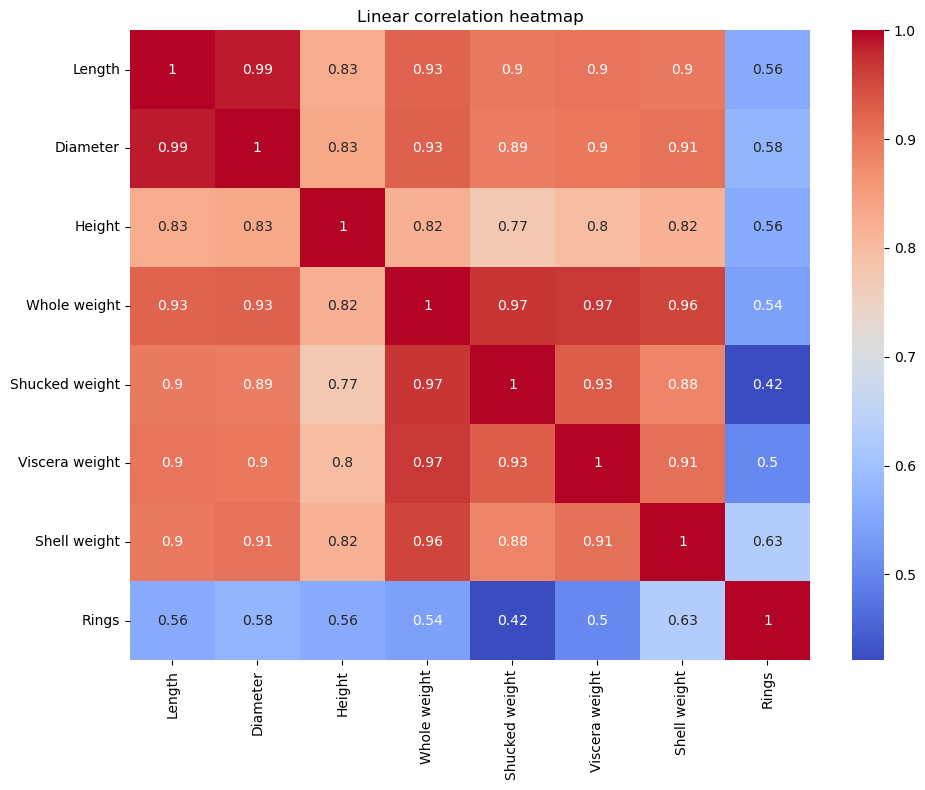

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Linear correlation heatmap")
plt.tight_layout()
plt.show()

### 8. Linear regression plot — strongest pairwise linear correlation

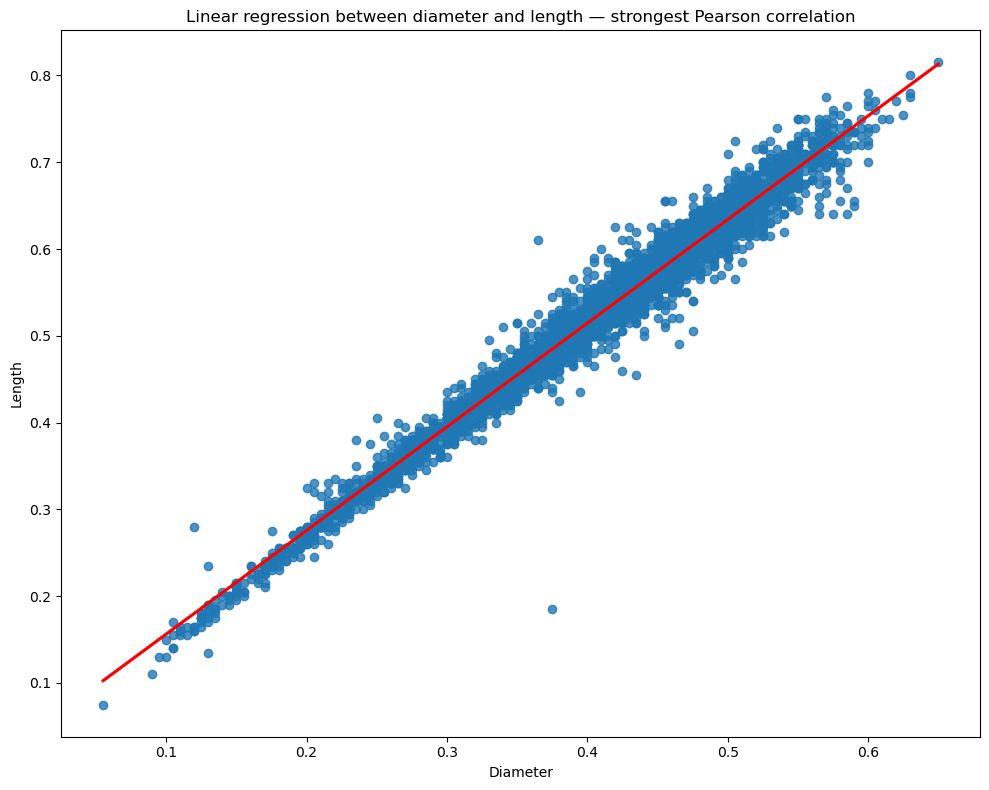

In [10]:
plt.figure(figsize=(10,8))
sns.regplot(data=no_sex_data,x="Diameter",y="Length",line_kws=dict(color="r"))
plt.title("Linear regression between diameter and length — strongest Pearson correlation")
plt.tight_layout()
plt.show()